<a href="https://colab.research.google.com/github/Sowmixh/AML-assignment/blob/main/Decision_tree_ipnyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving SuperMarket Analysis.csv to SuperMarket Analysis.csv
Accuracy: 0.335
Precision: 0.3359894146948942
Recall: 0.335
F1 Score: 0.3343637483637484


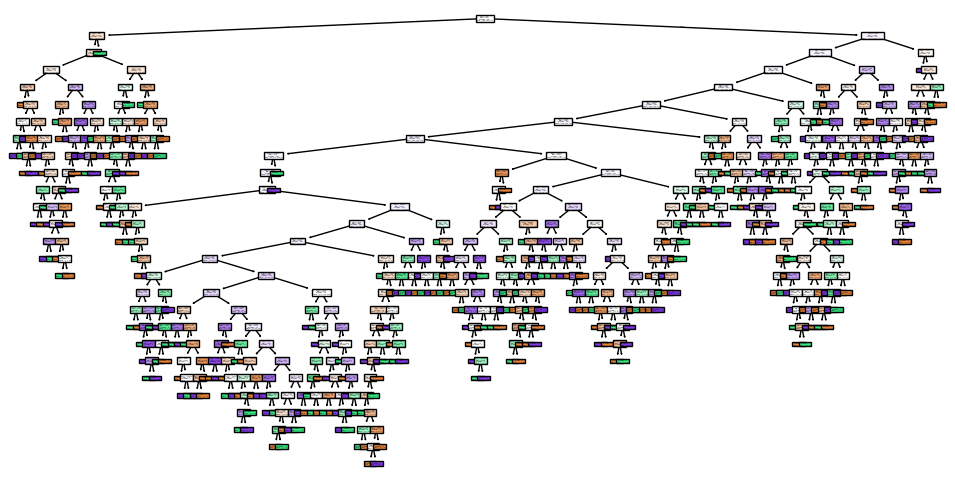

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from google.colab import files
uploaded = files.upload()

# Load
df = pd.read_csv("SuperMarket Analysis.csv")

df = df.drop(columns=['Invoice ID', 'Date', 'Time'])

# Encode
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Split
X = df.drop(columns=['Payment'])
y = df['Payment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# Plot Tree
plt.figure(figsize=(12,6))
plot_tree(model, filled=True)
plt.show()